### Import thư viện và Thiết lập môi trường

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Thiết lập Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Xây dựng Custom Dataset

In [2]:
class CustomDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.image_dir = os.path.join(root_dir, split, 'images')
        self.label_dir = os.path.join(root_dir, split, 'labels')
        self.transform = transform
        
        # Chỉ lấy các file ảnh có tồn tại file label tương ứng để tránh lỗi
        self.image_files = []
        for f in os.listdir(self.image_dir):
            if f.endswith(('.jpg', '.png', '.jpeg')):
                label_name = os.path.splitext(f)[0] + '.txt'
                if os.path.exists(os.path.join(self.label_dir, label_name)):
                    self.image_files.append(f)

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.image_dir, img_name)
        label_name = os.path.splitext(img_name)[0] + '.txt'
        label_path = os.path.join(self.label_dir, label_name)
        
        image = Image.open(img_path).convert("RGB")
        img_w, img_h = image.size
        
        with open(label_path, 'r') as f:
            lines = f.readlines()
            
        if len(lines) == 0:
            # Fallback nếu file txt rỗng
            label = 0 
        else:
            # Lấy object đầu tiên
            parts = lines[0].strip().split()
            label = int(parts[0])
            
            x_c, y_c, w, h = map(float, parts[1:5])
            
            px_x_c, px_y_c = x_c * img_w, y_c * img_h
            px_w, px_h = w * img_w, h * img_h
            
            left = max(0, int(px_x_c - px_w / 2))
            top = max(0, int(px_y_c - px_h / 2))
            right = min(img_w, int(px_x_c + px_w / 2))
            bottom = min(img_h, int(px_y_c + px_h / 2))
            
            if right > left and bottom > top:
                image = image.crop((left, top, right, bottom))

        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.float32)

### Khởi tạo Transform và DataLoader

In [3]:
DATASET_PATH = "/kaggle/input/datasets/nguynhcan/bok-choy-disease-detection-yolo-format" 
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Augmentation ánh sáng
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CustomDataset(root_dir=DATASET_PATH, split='train', transform=train_transform)
valid_dataset = CustomDataset(root_dir=DATASET_PATH, split='valid', transform=valid_transform)

print(f"Số lượng ảnh Train: {len(train_dataset)}")
print(f"Số lượng ảnh Valid: {len(valid_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Số lượng ảnh Train: 1368
Số lượng ảnh Valid: 386


### Xây dựng Kiến trúc CNN

In [4]:

class DepthwiseSeparableConv(nn.Module):
    """
    Tách biệt tính toán không gian (Depthwise) và tính toán kênh màu (Pointwise).
    Giảm đột biến số lượng tham số và FLOPs so với Conv2d thông thường.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1, 
                                   stride=stride, groups=in_channels, bias=False)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return self.relu(self.bn(x))

class CBAM(nn.Module):
    """
    Convolutional Block Attention Module.
    Ép mạng chú ý vào các đốm bệnh nhỏ (Spatial) và dải màu bất thường (Channel).
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        # Channel Attention Module
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )
        self.sigmoid_channel = nn.Sigmoid()
        
        # Spatial Attention Module
        self.conv_spatial = nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False)
        self.sigmoid_spatial = nn.Sigmoid()

    def forward(self, x):
        # Channel Attention
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        channel_out = self.sigmoid_channel(avg_out + max_out)
        x = x * channel_out
        
        # Spatial Attention
        avg_out_spatial = torch.mean(x, dim=1, keepdim=True)
        max_out_spatial, _ = torch.max(x, dim=1, keepdim=True)
        spatial_out = torch.cat([avg_out_spatial, max_out_spatial], dim=1)
        spatial_out = self.sigmoid_spatial(self.conv_spatial(spatial_out))
        x = x * spatial_out
        
        return x

class PlantBotCNN(nn.Module):
    def __init__(self):
        super(PlantBotCNN, self).__init__()
        
        # Stem Layer: Dùng Conv2d chuẩn để lấy các nét cạnh cơ bản ban đầu
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Block 1
        self.block1 = nn.Sequential(
            DepthwiseSeparableConv(32, 64),
            CBAM(64),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        # Block 2
        self.block2 = nn.Sequential(
            DepthwiseSeparableConv(64, 128),
            CBAM(128),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Block 3: Không dùng MaxPool ở đây để giữ lại độ phân giải texture của vết bệnh
        self.block3 = nn.Sequential(
            DepthwiseSeparableConv(128, 256),
            CBAM(256)
        )
        
        # Head: Dùng Global Average Pooling thay cho chuỗi Flatten -> Linear khổng lồ
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=0.4)
        self.classifier = nn.Linear(256, 1) # Binary Output Logit

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        
        x = self.gap(x)
        x = torch.flatten(x, 1)
        
        x = self.dropout(x)
        x = self.classifier(x)
        return x

# Khởi tạo và kiểm tra
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PlantBotCNN().to(device)
print(model)

# Test thử với 1 tensor ảnh đầu vào (Batch=1, Channels=3, H=224, W=224)
dummy_input = torch.randn(1, 3, 224, 224).to(device)
output = model(dummy_input)
print(f"Output shape: {output.shape}")

PlantBotCNN(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block1): Sequential(
    (0): DepthwiseSeparableConv(
      (depthwise): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (pointwise): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): CBAM(
      (avg_pool): AdaptiveAvgPool2d(output_size=1)
      (max_pool): AdaptiveMaxPool2d(output_size=1)
      (fc): Sequential(
        (0): Conv2d(64, 4, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): ReLU(inplace=True)
        (2): Conv2d(4, 64, kernel_size=(1, 1), str

### Cấu hình Huấn luyện và Training Loop

In [5]:
EPOCHS = 200
LEARNING_RATE = 1e-4

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# Lưu lịch sử để vẽ biểu đồ
train_losses, valid_losses = [], []
valid_accuracies = []

for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    running_train_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation Phase
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device).unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()
            
            # Tính accuracy
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    avg_val_loss = running_val_loss / len(valid_loader)
    val_acc = correct / total
    
    valid_losses.append(avg_val_loss)
    valid_accuracies.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

# Lưu weights
torch.save(model.state_dict(), 'bokchoy_cnn.pth')
print("Model saved to bokchoy_cnn.pth")

Epoch [1/200] | Train Loss: 0.6852 | Val Loss: 0.6905 | Val Acc: 0.6373
Epoch [2/200] | Train Loss: 0.6448 | Val Loss: 0.6295 | Val Acc: 0.7565
Epoch [3/200] | Train Loss: 0.5558 | Val Loss: 0.5293 | Val Acc: 0.7850
Epoch [4/200] | Train Loss: 0.4745 | Val Loss: 0.4620 | Val Acc: 0.8057
Epoch [5/200] | Train Loss: 0.4388 | Val Loss: 0.4358 | Val Acc: 0.8083
Epoch [6/200] | Train Loss: 0.4183 | Val Loss: 0.4109 | Val Acc: 0.8238
Epoch [7/200] | Train Loss: 0.4112 | Val Loss: 0.4012 | Val Acc: 0.8083
Epoch [8/200] | Train Loss: 0.4100 | Val Loss: 0.3810 | Val Acc: 0.8109
Epoch [9/200] | Train Loss: 0.3967 | Val Loss: 0.3695 | Val Acc: 0.8212
Epoch [10/200] | Train Loss: 0.3875 | Val Loss: 0.3625 | Val Acc: 0.8187
Epoch [11/200] | Train Loss: 0.3693 | Val Loss: 0.3412 | Val Acc: 0.8290
Epoch [12/200] | Train Loss: 0.3666 | Val Loss: 0.3375 | Val Acc: 0.8264
Epoch [13/200] | Train Loss: 0.3507 | Val Loss: 0.3309 | Val Acc: 0.8446
Epoch [14/200] | Train Loss: 0.3558 | Val Loss: 0.3233 | Val

### Trực quan hóa Loss và Accuracy

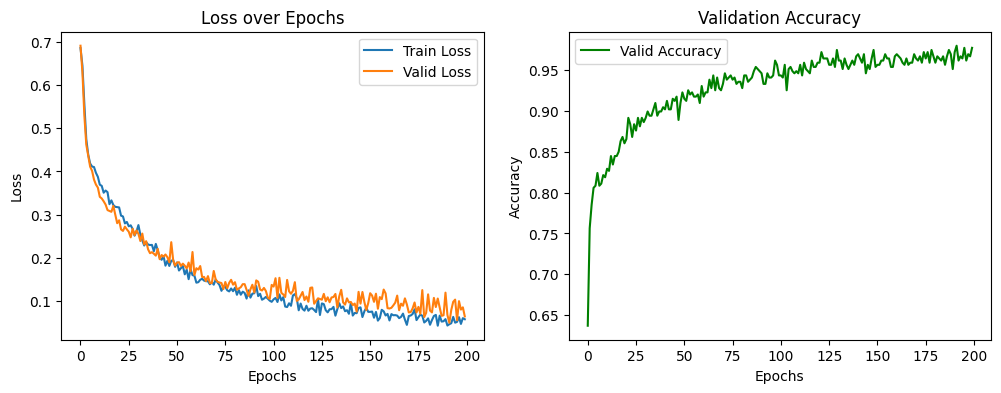

In [6]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Valid Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(valid_accuracies, label='Valid Accuracy', color='green')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()